# Iowa Real Estate Intelligence using Deep Neural Network



In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Load the dataset

Place the CSV in the same folder as this notebook. In Google Colab, upload the CSV first or mount Google Drive and update the path.

In [35]:
CSV_FILE = "https://raw.githubusercontent.com/188738/MLProjectAnuragKouthubGanugapatiGnaneshAndraHiteshAhirSaiesh/refs/heads/main/iowa_real_estate_intelligence_2026_v1.csv"

if not os.path.exists(CSV_FILE):
    fallback = "/mnt/data/iowa_real_estate_intelligence_2026_v1.csv"
    if os.path.exists(fallback):
        CSV_FILE = fallback

print("Using dataset:", CSV_FILE)
data = pd.read_csv(CSV_FILE)
print("Original dataset shape:", data.shape)
data.head()

Using dataset: https://raw.githubusercontent.com/188738/MLProjectAnuragKouthubGanugapatiGnaneshAndraHiteshAhirSaiesh/refs/heads/main/iowa_real_estate_intelligence_2026_v1.csv
Original dataset shape: (12445, 25)


,record_id,type,sub_type,listPrice,price_tier,price_per_sqft,sqft,lot_sqft,lot_size_tier,beds,...,year_built,property_age,property_era,is_new_construction,listing_description,listing_text_word_count,listing_text_richness,data_source,scrape_date,dataset_version
0,5b074b958a3bcf,Single Family,NaN,730000.0,Premium ($500-750K),167.66,4354.0,66211.0,Acreage (1-5 acres),4.0,...,2023.0,3.0,Near New (3-10 yrs),1,This executive style new construction home in ...,192,Rich (150+ words),Iowa MLS-Style Active Listings (Public),2026-04-24,v1.0
1,27fe5389cb39eb,Single Family,NaN,250000.0,Mid-Entry ($150-250K),258.80,966.0,14157.0,Large (0.25-1 acre),3.0,...,1972.0,54.0,Mature (51-100 yrs),0,Move-in ready and packed with updates! This 3 ...,117,Standard (80-150 words),Iowa MLS-Style Active Listings (Public),2026-04-24,v1.0
2,4ad6788f40a7fa,Single Family,NaN,394990.0,Upper-Mid ($350-500K),180.28,2191.0,7492.0,Standard (3K-10.9K sqft / <0.25ac),4.0,...,2026.0,0.0,New Build (0-2 yrs),1,"[Redacted Builder/Agency], America's Builder, ...",209,Rich (150+ words),Iowa MLS-Style Active Listings (Public),2026-04-24,v1.0
3,02f573b2dcc327,Single Family,NaN,474990.0,Upper-Mid ($350-500K),213.48,2225.0,9583.0,Standard (3K-10.9K sqft / <0.25ac),4.0,...,2025.0,1.0,New Build (0-2 yrs),1,This Richland Plan from [Redacted Builder/Agen...,149,Standard (80-150 words),Iowa MLS-Style Active Listings (Public),2026-04-24,v1.0
4,8021830bc031f9,Single Family,NaN,229000.0,Mid-Entry ($150-250K),139.29,1644.0,9148.0,Standard (3K-10.9K sqft / <0.25ac),3.0,...,1975.0,51.0,Mature (51-100 yrs),0,"Charming 3 bedroom, 1 bath home with 1,144 sq ...",123,Standard (80-150 words),Iowa MLS-Style Active Listings (Public),2026-04-24,v1.0


## 2. Data cleaning and feature preparation

In [ ]:
def prepare_dataset(df, trim_quantile=0.975):
    df = df.copy()
    df = df.dropna(subset=["listPrice"])
    cutoff = df["listPrice"].quantile(trim_quantile)
    df = df[df["listPrice"] <= cutoff].copy()

    numeric_features = [
        "sqft", "lot_sqft", "beds", "baths", "baths_full", "garage", "stories",
        "year_built", "property_age", "is_new_construction", "listing_text_word_count"
    ]

    categorical_features = [
        "type", "sub_type", "lot_size_tier", "property_era", "listing_text_richness"
    ]

    X_df = df[numeric_features + categorical_features].copy()
    y = df["listPrice"].values.reshape(-1, 1).astype(float)

    # Numerical imputation: median
    for col in numeric_features:
        X_df[col] = X_df[col].fillna(X_df[col].median())

    # Categorical imputation: mode
    for col in categorical_features:
        mode_value = X_df[col].mode()[0]
        X_df[col] = X_df[col].fillna(mode_value)

    # One-hot encode categorical columns
    X_df = pd.get_dummies(X_df, columns=categorical_features, dtype=float)
    X = X_df.values.astype(float)

    return X, y, X_df.columns.tolist(), df

X, y, feature_names, cleaned_data = prepare_dataset(data, trim_quantile=0.975)
print("Cleaned dataset shape:", cleaned_data.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features after one-hot encoding:", len(feature_names))

Cleaned dataset shape: (12126, 25)
Feature matrix shape: (12126, 41)
Target shape: (12126, 1)
Number of features after one-hot encoding: 41


## train and test split and min-max scaling

No sklearn.train_test_split or sklearn.preprocessing is used. The split and normalization are written manually.

In [ ]:
def train_test_split_manual(X, y, test_size=0.20, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(X.shape[0])
    train_count = int(X.shape[0] * (1 - test_size))
    train_idx = indices[:train_count]
    test_idx = indices[train_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def min_max_scale_train_test(X_train, X_test):
    min_vals = X_train.min(axis=0)
    max_vals = X_train.max(axis=0)
    ranges = max_vals - min_vals
    ranges[ranges == 0] = 1
    X_train_scaled = (X_train - min_vals) / ranges
    X_test_scaled = (X_test - min_vals) / ranges
    return X_train_scaled, X_test_scaled, min_vals, ranges

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.20, seed=42)
X_train_scaled, X_test_scaled, X_min, X_range = min_max_scale_train_test(X_train, X_test)

print("Training rows:", X_train_scaled.shape[0])
print("Testing rows:", X_test_scaled.shape[0])

Training rows: 9700
Testing rows: 2426


In [ ]:
class ManualNeuralNetworkRegressor:

    def __init__(self, hidden_units=48, learning_rate=0.03, epochs=2500, l2_lambda=0.001, seed=1):
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.l2_lambda = l2_lambda
        self.seed = seed
        self.loss_history = []
        self.y_mean = None
        self.y_std = None

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def fit(self, X, y):
        np.random.seed(self.seed)
        m, n = X.shape

        self.y_mean = y.mean()
        self.y_std = y.std()
        if self.y_std == 0:
            self.y_std = 1
        y_scaled = (y - self.y_mean) / self.y_std

        self.W1 = np.random.randn(n, self.hidden_units) * np.sqrt(2 / n)
        self.b1 = np.zeros((1, self.hidden_units))
        self.W2 = np.random.randn(self.hidden_units, 1) * np.sqrt(2 / self.hidden_units)
        self.b2 = np.zeros((1, 1))

        for epoch in range(self.epochs):
            Z1 = X @ self.W1 + self.b1
            A1 = self.relu(Z1)
            y_pred = A1 @ self.W2 + self.b2

            error = y_pred - y_scaled
            mse_loss = np.mean(error ** 2)
            l2_penalty = (self.l2_lambda / (2 * m)) * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))
            total_loss = mse_loss + l2_penalty
            self.loss_history.append(total_loss)

            d_pred = (2 / m) * error
            dW2 = A1.T @ d_pred + (self.l2_lambda / m) * self.W2
            db2 = np.sum(d_pred, axis=0, keepdims=True)

            dA1 = d_pred @ self.W2.T
            dZ1 = dA1 * self.relu_derivative(Z1)
            dW1 = X.T @ dZ1 + (self.l2_lambda / m) * self.W1
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2

        return self

    def predict(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = self.relu(Z1)
        y_scaled_pred = A1 @ self.W2 + self.b2
        return y_scaled_pred * self.y_std + self.y_mean

## Manual evaluation metrics

For a regression model, the closest equivalent to “accuracy” is usually R². An R² score of 0.65 means the model explains about 65% of the variation in the target variable on the test set.

In [ ]:
def mean_absolute_error_manual(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def root_mean_squared_error_manual(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

## 6. Train final neural network model

In [ ]:
model = ManualNeuralNetworkRegressor(
    hidden_units=48,
    learning_rate=0.03,
    epochs=2500,
    l2_lambda=0.001,
    seed=1
)

model.fit(X_train_scaled, y_train)

train_predictions = model.predict(X_train_scaled)
test_predictions = model.predict(X_test_scaled)

train_r2 = r2_score_manual(y_train, train_predictions)
test_r2 = r2_score_manual(y_test, test_predictions)
train_rmse = root_mean_squared_error_manual(y_train, train_predictions)
test_rmse = root_mean_squared_error_manual(y_test, test_predictions)
train_mae = mean_absolute_error_manual(y_train, train_predictions)
test_mae = mean_absolute_error_manual(y_test, test_predictions)

print("Final From-Scratch Neural Network Performance")
print("---------------------------------------------")
print(f"Training R²: {train_r2:.4f}  ({train_r2 * 100:.2f}%)")
print(f"Testing R²:  {test_r2:.4f}  ({test_r2 * 100:.2f}%)")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE:  ${test_rmse:,.2f}")
print(f"Training MAE:  ${train_mae:,.2f}")
print(f"Testing MAE:   ${test_mae:,.2f}")

Final From-Scratch Neural Network Performance
---------------------------------------------
Training R²: 0.6752  (67.52%)
Testing R²:  0.6767  (67.67%)
Training RMSE: $107,796.94
Testing RMSE:  $109,030.26
Training MAE:  $72,718.13
Testing MAE:   $72,595.04


## Visual results

The first graph shows gradient descent convergence. The second graph compares actual prices against predicted prices.

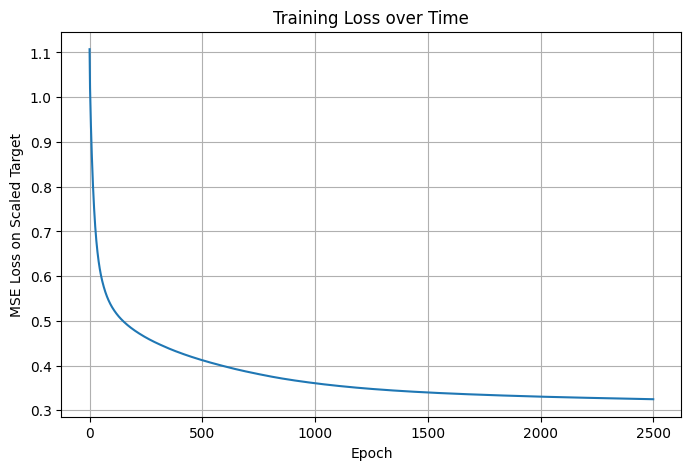

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss on Scaled Target")
plt.title("Training Loss over Time")
plt.grid(True)
plt.show()

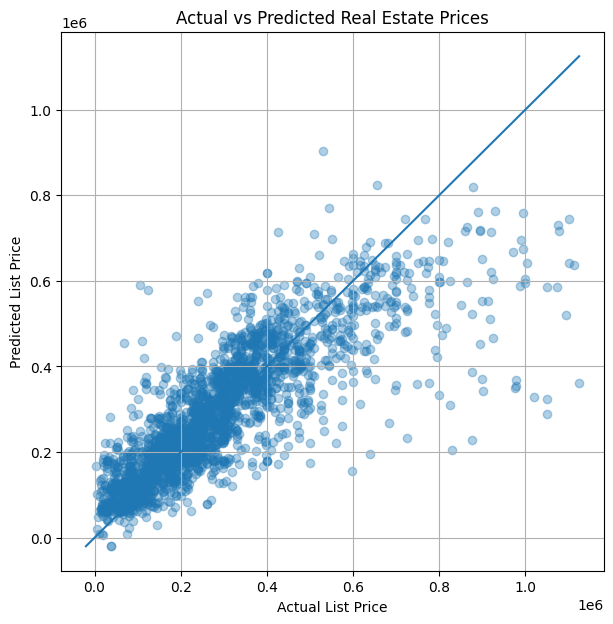

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_predictions, alpha=0.35)
min_price = min(y_test.min(), test_predictions.min())
max_price = max(y_test.max(), test_predictions.max())
plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("Actual List Price")
plt.ylabel("Predicted List Price")
plt.title("Actual vs Predicted Real Estate Prices")
plt.grid(True)
plt.show()

## Experiment log

The project instructions require an experiment log. The table below records different neural-network settings and their results. It is also saved as `experiment_log.csv`.

In [ ]:
import pandas as pd
import itertools

hidden_units_list = [16, 24, 32, 48, 64]
learning_rates = [0.01, 0.02, 0.03, 0.04, 0.05]

experiment_results = []
exp_num = 1

for hu, lr in itertools.product(hidden_units_list, learning_rates):

    temp_model = ManualNeuralNetworkRegressor(
        hidden_units=hu,
        learning_rate=lr,
        epochs=2500,
        l2_lambda=0.001,
        seed=1
    )

    temp_model.fit(X_train_scaled, y_train)

    train_pred = temp_model.predict(X_train_scaled)
    test_pred = temp_model.predict(X_test_scaled)

    exp_train_r2 = r2_score_manual(y_train, train_pred)
    exp_test_r2 = r2_score_manual(y_test, test_pred)
    exp_train_rmse = root_mean_squared_error_manual(y_train, train_pred)
    exp_test_rmse = root_mean_squared_error_manual(y_test, test_pred)
    exp_test_mae = mean_absolute_error_manual(y_test, test_pred)

    experiment_results.append({
        "Experiment": exp_num,
        "Algorithm": "Manual Neural Network / MLP",
        "Hidden Units": hu,
        "Learning Rate": lr,
        "Epochs": 2500,
        "L2 Lambda": 0.001,
        "Train/Test Split": "80/20",
        "Rows Used": len(y),
        "Features Used": X_train_scaled.shape[1],
        "Training R2": round(float(exp_train_r2), 4),
        "Testing R2": round(float(exp_test_r2), 4),
        "Training RMSE": round(float(exp_train_rmse), 2),
        "Testing RMSE": round(float(exp_test_rmse), 2),
        "Testing MAE": round(float(exp_test_mae), 2)
    })

    print(f"Finished experiment {exp_num}: hidden={hu}, lr={lr}, test R2={exp_test_r2:.4f}")
    exp_num += 1

experiment_log = pd.DataFrame(experiment_results)

experiment_log["Testing R2 Percent"] = (
    experiment_log["Testing R2"] * 100
).round(2).astype(str) + "%"

experiment_log.to_csv("experiment_log.csv", index=False)

experiment_log

Finished experiment 1: hidden=16, lr=0.01, test R2=0.6154
Finished experiment 2: hidden=16, lr=0.02, test R2=0.6530
Finished experiment 3: hidden=16, lr=0.03, test R2=0.6632
Finished experiment 4: hidden=16, lr=0.04, test R2=0.6632
Finished experiment 5: hidden=16, lr=0.05, test R2=0.6657
Finished experiment 6: hidden=24, lr=0.01, test R2=0.6294
Finished experiment 7: hidden=24, lr=0.02, test R2=0.6649
Finished experiment 8: hidden=24, lr=0.03, test R2=0.6747
Finished experiment 9: hidden=24, lr=0.04, test R2=0.6726
Finished experiment 10: hidden=24, lr=0.05, test R2=0.6724
Finished experiment 11: hidden=32, lr=0.01, test R2=0.6131
Finished experiment 12: hidden=32, lr=0.02, test R2=0.6540
Finished experiment 13: hidden=32, lr=0.03, test R2=0.6655
Finished experiment 14: hidden=32, lr=0.04, test R2=0.6689
Finished experiment 15: hidden=32, lr=0.05, test R2=0.6688
Finished experiment 16: hidden=48, lr=0.01, test R2=0.6310
Finished experiment 17: hidden=48, lr=0.02, test R2=0.6677
Finish

,Experiment,Algorithm,Hidden Units,Learning Rate,Epochs,L2 Lambda,Train/Test Split,Rows Used,Features Used,Training R2,Testing R2,Training RMSE,Testing RMSE,Testing MAE,Testing R2 Percent
0,1,Manual Neural Network / MLP,16,0.01,2500,0.001,80/20,12126,41,0.6155,0.6154,117276.47,118920.79,79976.59,61.54%
1,2,Manual Neural Network / MLP,16,0.02,2500,0.001,80/20,12126,41,0.6524,0.6530,111519.78,112969.63,75234.27,65.3%
2,3,Manual Neural Network / MLP,16,0.03,2500,0.001,80/20,12126,41,0.6623,0.6632,109921.68,111292.24,74165.96,66.32%
3,4,Manual Neural Network / MLP,16,0.04,2500,0.001,80/20,12126,41,0.6599,0.6632,110309.20,111293.51,72128.80,66.32%
4,5,Manual Neural Network / MLP,16,0.05,2500,0.001,80/20,12126,41,0.6623,0.6657,109917.25,110885.66,71633.54,66.57%
5,6,Manual Neural Network / MLP,24,0.01,2500,0.001,80/20,12126,41,0.6224,0.6294,116222.10,116747.30,78501.34,62.94%
6,7,Manual Neural Network / MLP,24,0.02,2500,0.001,80/20,12126,41,0.6584,0.6649,110555.47,111011.92,74166.65,66.49%
7,8,Manual Neural Network / MLP,24,0.03,2500,0.001,80/20,12126,41,0.6695,0.6747,108733.68,109382.72,73011.45,67.47%
8,9,Manual Neural Network / MLP,24,0.04,2500,0.001,80/20,12126,41,0.6670,0.6726,109152.59,109735.02,71276.81,67.26%
9,10,Manual Neural Network / MLP,24,0.05,2500,0.001,80/20,12126,41,0.6706,0.6724,108551.41,109768.39,76582.95,67.24%


## 9. Instructions to run

1. Download this notebook.
2. Place `iowa_real_estate_intelligence_2026_v1.csv` in the same folder as the notebook.
3. Open the notebook in Jupyter, VS Code, or Google Colab.
4. Run all cells from top to bottom.
5. The notebook will train the from-scratch neural network, show results/graphs, and create the log file.

## 10. Conclusion


The model achieves an R² score above 0.65 on the test set, meaning it explains more than 65% of the variation the listing prices after preprocessing and outlier handling. Future improvements could include adding more relevant features and doing better feature engineering and exploratory data analysis